In [1]:
import cvxpy as cp
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import zap
from zap.importers.pypsa import load_pypsa_network, parse_buses
import os
from pathlib import Path
import pypsa
from zap.devices import ACLine
import pandas as pd
import geopandas as gpd
from copy import deepcopy

In [2]:
LOAD_SCALING_FACTOR = 1.27
GEN_SCALING_FACTOR = 1.24
# GEN_SCALING_FACTOR = 1
LINE_SCALING_FACTOR = 1.0
INVESTMENT_NODE_CANDS = [32, 82, 50, 18, 15, 22, 43, 14, 23, 20, 45, 65, 78] # This is already sorted by land cost
# INVESTMENT_NODE_CANDS = [0, 82, 50, 18, 15, 22, 43, 14, 23, 20, 45, 65, 78] # This is already sorted by land cost

In [3]:
def upsample_zap_devices(devices, factor=4, original_timesteps=24):
    """Upsample time-varying attributes of zap devices by repeating each timestep."""
    upsampled_zap_devices = []
    for dev in devices:
        upsampled_dev = dev.sample_time(original_timesteps*factor, original_timesteps)
        upsampled_zap_devices.append(upsampled_dev)

    return upsampled_zap_devices

In [4]:
HOME_PATH = os.environ.get("HOME")
PYPSA_NETW0RK_PATH = (
    HOME_PATH + "/zap_data/pypsa-networks/western_small/network_2023.nc"
)
pn = pypsa.Network(PYPSA_NETW0RK_PATH)
snapshots = pn.generators_t.p_max_pu.index
# snapshot_data = snapshots[5616:5640]  # 8/23/21 # hourly
snapshot_data = snapshots[5448:5472]  # 8/16/21 # hourly

INFO:pypsa.io:Imported network network_2023.nc has buses, carriers, generators, lines, links, loads, storage_units


## Get terminal/bus cost information for possible investment candidate nodes

In [5]:
buses, buses_to_index = parse_buses(pn) # buses_to_index is dict of "pyspa_bus_name": "zap_terminal"
index_to_bus = {idx: name for name, idx in buses_to_index.items()}
pypsa_bus_names = [index_to_bus[i] for i in INVESTMENT_NODE_CANDS]

b = pn.buses.copy()
gdf = gpd.GeoDataFrame(
    b, geometry=gpd.points_from_xy(b["x"], b["y"]), crs="EPSG:4326"
)

county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
counties = gpd.read_file(county_url)[["STATEFP","COUNTYFP","GEOID","NAME","STATE_NAME","geometry"]]

j = gpd.sjoin(gdf, counties.to_crs("EPSG:4326"), how="left", predicate="within")

pn.buses["county_fips"] = j["GEOID"]  # 5-digit FIPS
pn.buses["county_name"] = j["NAME"]
pn.buses["state_fips"]  = j["STATEFP"]
pn.buses["state_name"]  = j["STATE_NAME"]

selected_node_fips = pn.buses.loc[pypsa_bus_names, "county_fips"]
county_land_lut_df = pd.read_csv("county_land_lut.csv")

In [6]:
sel = selected_node_fips.rename("county_fips").to_frame()
bus_to_terminal = {bus: term for term, bus in index_to_bus.items()}
sel["terminal"] = sel.index.map(bus_to_terminal)
sel["county_fips"] = sel["county_fips"].astype(str).str.zfill(5)
county_land_lut_df["county_fips"] = county_land_lut_df["county_fips"].astype(str).str.zfill(5)

sel = sel.merge(
    county_land_lut_df,
    left_on="county_fips",
    right_on="county_fips",
    how="left",
)

terminal_cost = (
    sel.groupby("terminal")["land_usd2017_per_acre"]
      .first()   # or .mean(), depending on what you want
      .sort_index()
)

In [7]:
sel.head(15)

,county_fips,terminal,land_usd2017_per_acre
0,32001,32,207.092794
1,41025,82,314.747844
2,49003,50,361.913934
3,06071,18,385.682727
4,06071,15,385.682727
5,06071,22,385.682727
6,30111,43,444.834331
7,06065,14,522.828450
8,06065,23,522.828450
9,06065,20,522.828450


In [8]:
CAPITAL_COSTS = np.array(sel.land_usd2017_per_acre)

In [9]:
CAPITAL_COSTS

array([207.09279407, 314.74784435, 361.91393443, 385.68272663,
       385.68272663, 385.68272663, 444.83433129, 522.82845019,
       522.82845019, 522.82845019, 800.63193686, 924.08795012,
       983.42339596])

## Convert PyPSA network to Zap

In [10]:
pypsa_kwargs = {}
pypsa_net, pypsa_devices = load_pypsa_network(
    pn, snapshot_data, power_unit=1.0e3, cost_unit=100.0, **pypsa_kwargs
)

pypsa_devices = upsample_zap_devices(pypsa_devices, factor=4, original_timesteps=24)

Dropping empty generators.


## Helper to create devices for planning problem

In [11]:
def create_planning_devices(pypsa_devices, planning_devices_params_dict):
    num_nodes = planning_devices_params_dict["num_nodes"]
    investment_node_cands = planning_devices_params_dict["investment_node_cands"]
    gen_scaling_factor = planning_devices_params_dict["gen_scaling_factor"]
    load_scaling_factor = planning_devices_params_dict["load_scaling_factor"]
    line_scaling_factor = planning_devices_params_dict["line_scaling_factor"]
    dc_nominal_capacity = planning_devices_params_dict["dc_nominal_capacity"]
    capital_costs = planning_devices_params_dict["capital_costs"]
    workload_profile = planning_devices_params_dict["workload_profile"]
    pypsa_net = planning_devices_params_dict["pypsa_net"]
    pypsa_devices = planning_devices_params_dict["pypsa_devices"]

    pypsa_devices_dc = deepcopy(pypsa_devices)

    # Scale load, gen, and line capacities
    pypsa_devices_dc[1].load *= load_scaling_factor
    pypsa_devices_dc[0].dynamic_capacity *= gen_scaling_factor
    pypsa_devices_dc[3].nominal_capacity *= line_scaling_factor
    pypsa_devices_dc[3].nominal_capacity[168] = 0.2
    pypsa_devices_dc[3].nominal_capacity[176] = 0.2

    # Select which nodes to build at
    dc_terminals = np.array(investment_node_cands[:num_nodes])
    n_dc = len(dc_terminals)
    dc_capital_costs = capital_costs[:n_dc]

    # Build nominal capacities for DC loads
    if np.isscalar(dc_nominal_capacity):
        nominal_capacity = np.full(n_dc, dc_nominal_capacity)
    else:
        nominal_capacity = dc_nominal_capacity

    # Build DCLoad object
    dcloads = zap.DataCenterLoad(
        num_nodes=pypsa_net.num_nodes,
        terminal=dc_terminals,
        profiles=n_dc*[workload_profile],
        nominal_capacity=nominal_capacity,
        linear_cost=np.ones(n_dc) * 0,
        settime_horizon=96,
        capital_cost=dc_capital_costs
    )

    pypsa_devices_dc.append(dcloads)
    return pypsa_devices_dc


## Run and analyze single node injection

In [12]:
# This will add a DC at the cheapest land cost node
planning_devices_params_dict = {
    "num_nodes": 1,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 1, # GW
    "capital_costs": CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}


planning_devices = create_planning_devices(pypsa_devices, planning_devices_params_dict)
base_outcome = pypsa_net.dispatch(
    pypsa_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)
single_node_outcome = pypsa_net.dispatch(
    planning_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

Dispatch Cost before injection: 1716.7941642385247
Dispatch Cost after injection: 2251.6071587946954
Dispatch Cost Increased by 31.15%


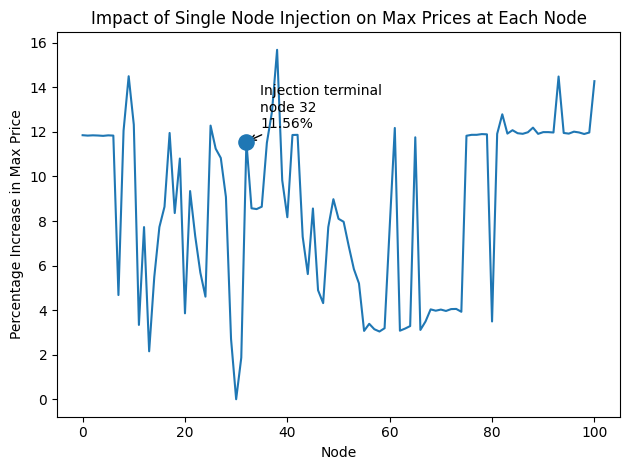

In [13]:
## Analyze results between base outcome and single node injection outcome 

base_outcome_dispatch_cost = base_outcome.problem.value
single_node_outcome_dispatch_cost = single_node_outcome.problem.value

base_outcome_max_prices = base_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
single_node_outcome_max_prices = single_node_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
max_prices_diff_pct = (single_node_outcome_max_prices - base_outcome_max_prices) / base_outcome_max_prices * 100 # [101,] percentage increase in max price at each node

## Observe some results from the dispatch outcome
print(f"Dispatch Cost before injection: {base_outcome_dispatch_cost}")
print(f"Dispatch Cost after injection: {single_node_outcome_dispatch_cost}")
print(f"Dispatch Cost Increased by {(single_node_outcome_dispatch_cost - base_outcome_dispatch_cost)/base_outcome_dispatch_cost * 100:.2f}%")

injection_terminal = INVESTMENT_NODE_CANDS[0]
plt.plot(max_prices_diff_pct, label="Percentage Increase in Max Price at Each Node")
plt.scatter(
    injection_terminal,
    max_prices_diff_pct[injection_terminal],
    s=120,
    zorder=5,
    label=f"Injection terminal (node {injection_terminal})"
)
plt.annotate(
    f"Injection terminal\nnode {injection_terminal}\n{max_prices_diff_pct[injection_terminal]:.2f}%",
    (injection_terminal, max_prices_diff_pct[injection_terminal]),
    xytext=(10, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
plt.xlabel("Node")
plt.ylabel("Percentage Increase in Max Price")
plt.title("Impact of Single Node Injection on Max Prices at Each Node")
plt.tight_layout()

In [14]:
line_nom_caps = planning_devices[3].nominal_capacity.squeeze() # [251,]
single_node_outcome_line_flows = single_node_outcome.power[3][1] # [251, 96]

line_util = np.abs(single_node_outcome_line_flows) / line_nom_caps[:, None]  # (251, 96) utilization in [0, inf)

max_util_per_line = line_util.max(axis=1) # (251,)
mean_util_per_line = line_util.mean(axis=1) # (251,)
frac_congested = (line_util >= 1.0).mean()

print(frac_congested)

0.0


0.12897999999999998

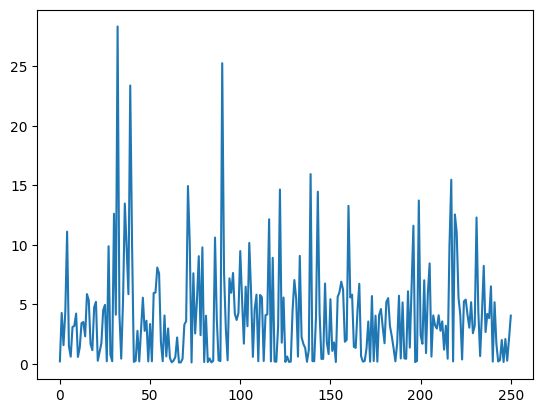

In [15]:
plt.plot(line_nom_caps)
min(line_nom_caps)

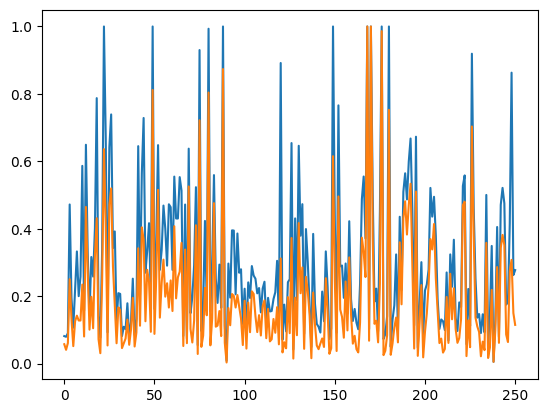

In [16]:
## Analyze line limits or something 
plt.plot(max_util_per_line)
plt.plot(mean_util_per_line)

## Helper to run planning instance

In [17]:
def run_planning_experiment(pypsa_net, pypsa_devices_dc, planning_exp_params_dict):
    total_dc_budget = planning_exp_params_dict["total_dc_budget"]
    dc_lower_bound = planning_exp_params_dict["dc_lower_bound"]
    dc_upper_bound = planning_exp_params_dict["dc_upper_bound"] 
    op_obj_selector = planning_exp_params_dict["op_obj_selector"]
    num_iters = planning_exp_params_dict["num_iters"]

    n_dc = len(pypsa_devices_dc[-1].terminals)

    # Create dispatch layer
    xstar = zap.DispatchLayer(
        pypsa_net,
        pypsa_devices_dc,
        parameter_names={"dc_capacity": (5, "nominal_capacity")},
        time_horizon=96,
        solver=cp.CLARABEL,
    )

    lower_bounds = {"dc_capacity": np.full(n_dc, dc_lower_bound)}
    upper_bounds = {"dc_capacity": np.full(n_dc, dc_upper_bound)}

    # Initialize capacities eta randomly within bounds
    init_eta = np.random.rand(n_dc).clip(dc_lower_bound, dc_upper_bound)
    eta = {"dc_capacity": init_eta}

    # Create objectives
    inv_obj = zap.planning.InvestmentObjective(pypsa_devices_dc, xstar)
    if op_obj_selector == "dispatch":
        op_obj = zap.planning.DispatchCostObjective(pypsa_net, pypsa_devices_dc)
    elif op_obj_selector == "lmp":
        op_obj = zap.planning.LMPObjective(pypsa_net, pypsa_devices_dc, lmp_metric="meanmax")

    P = zap.planning.PlanningProblem(
        operation_objective=op_obj,
        investment_objective=inv_obj,
        layer=xstar,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
    )

    P.extra_projections = {
        "dc_capacity": zap.planning.SimplexBudgetProjection(
            budget=total_dc_budget, strict=True
        )
    }

    cost = P(**eta, requires_grad=True)
    grad = P.backward()

    state = P.solve(num_iterations=num_iters, initial_state=eta)
    

    return state

In [18]:
def run_planning_experiment_benders(pypsa_net, pypsa_devices_dc, planning_exp_params_dict):
    total_dc_budget = planning_exp_params_dict["total_dc_budget"]
    dc_lower_bound = planning_exp_params_dict["dc_lower_bound"]
    dc_upper_bound = planning_exp_params_dict["dc_upper_bound"] 
    capital_cost = planning_exp_params_dict["capital_cost"]

    n_dc = len(pypsa_devices_dc[-1].terminals)
    dc_capital_costs = capital_cost[:n_dc]

    # Create dispatch layer
    xstar = zap.DispatchLayer(
        pypsa_net,
        pypsa_devices_dc,
        parameter_names={"dc_capacity": (5, "nominal_capacity")},
        time_horizon=96,
        solver=cp.CLARABEL,
    )

    lower_bounds = {"dc_capacity": np.full(n_dc, dc_lower_bound)}
    upper_bounds = {"dc_capacity": np.full(n_dc, dc_upper_bound)}

    # Initialize capacities eta randomly within bounds
    init_eta = None
    B = zap.planning.BendersSolver(
        layer=xstar,
        capital_cost=dc_capital_costs,
        budget=total_dc_budget,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        dispatch_scalar=1.0,
    )

    state = B.solve(initial_u=init_eta, max_iter=100, tol=1e-6)
    

    return state

## Run a planning experiment

In [19]:
num_nodes = 10

# ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
# new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 1, # Doesn't actually matter for planning since we optimize over it 
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}
pypsa_devices_dc = create_planning_devices(pypsa_devices, planning_devices_params_dict)

planning_exp_params_dict = {
    "total_dc_budget": 1, # GW
    "dc_lower_bound": 0.05, # GW
    "dc_upper_bound": 0.1, # GW
    "op_obj_selector": "dispatch", # "dispatch" or "lmp", which defaults to meanmax
    "num_iters": 10
}

planning_state = run_planning_experiment(pypsa_net, pypsa_devices_dc, planning_exp_params_dict)


No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
Starting iteration 1
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporter.ac_line.ACLine'>
Starting iteration 2
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
No capital cost or nominal capacity for device <class 'zap.devices.transporte

In [20]:
# Simulate the dispatch outcome with the planned DC capacities
planned_dc_capacities = planning_state[0]["dc_capacity"]

ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": planned_dc_capacities, 
    "capital_costs": CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}

planned_devices = create_planning_devices(pypsa_devices, planning_devices_params_dict)
distributed_outcome = pypsa_net.dispatch(
    planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

Dispatch Cost before injection: 1716.7941642385247
Dispatch Cost after distributed DC: 2251.4081233388165
Dispatch Cost Increased by 31.14%


<BarContainer object of 10 artists>

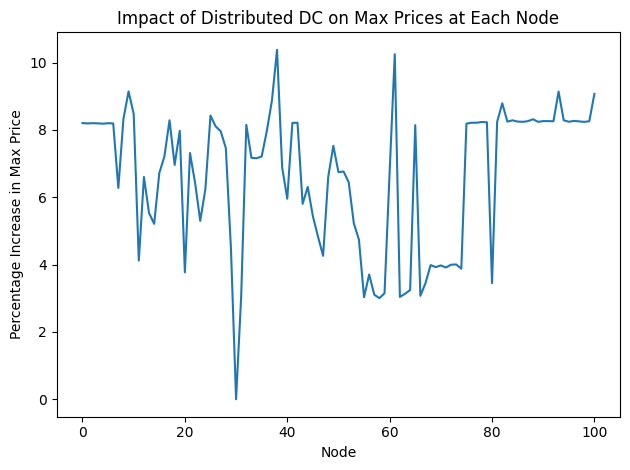

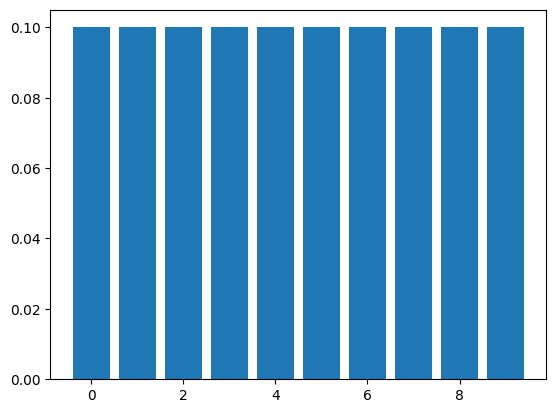

In [21]:
## Analyze results between base outcome and distributed case

base_outcome_dispatch_cost = base_outcome.problem.value
distributed_outcome_dispatch_cost = distributed_outcome.problem.value

base_outcome_max_prices = base_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
distributed_outcome_max_prices = distributed_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
max_prices_diff_pct = (distributed_outcome_max_prices - base_outcome_max_prices) / base_outcome_max_prices * 100 # [101,] percentage increase in max price at each node

## Observe some results from the dispatch outcome
print(f"Dispatch Cost before injection: {base_outcome_dispatch_cost}")
print(f"Dispatch Cost after distributed DC: {distributed_outcome_dispatch_cost}")
print(f"Dispatch Cost Increased by {(distributed_outcome_dispatch_cost - base_outcome_dispatch_cost)/base_outcome_dispatch_cost * 100:.2f}%")

injection_terminal = INVESTMENT_NODE_CANDS[0]
plt.plot(max_prices_diff_pct, label="Percentage Increase in Max Price at Each Node")
plt.xlabel("Node")
plt.ylabel("Percentage Increase in Max Price")
plt.title("Impact of Distributed DC on Max Prices at Each Node")
plt.tight_layout()


plt.figure()
plt.bar(range(len(planned_dc_capacities)), planned_dc_capacities)

In [22]:
line_nom_caps = planned_devices[3].nominal_capacity.squeeze() # [251,]
single_node_outcome_line_flows = distributed_outcome.power[3][1] # [251, 96]

line_util = np.abs(single_node_outcome_line_flows) / line_nom_caps[:, None]  # (251, 96) utilization in [0, inf)

distributed_max_util_per_line = line_util.max(axis=1) # (251,)
distributed_mean_util_per_line = line_util.mean(axis=1) # (251,)
frac_congested = (line_util >= 1.0).mean()

print(frac_congested)

0.0


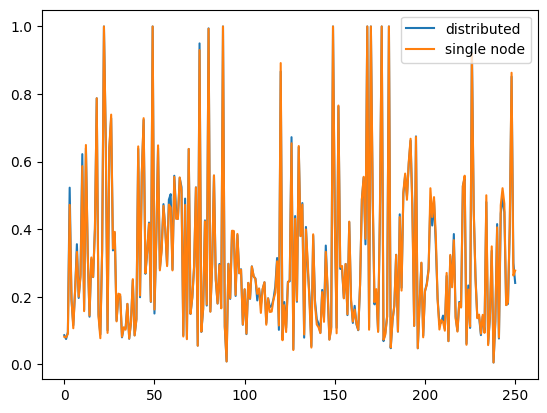

In [23]:
## Analyze line limits or something 
plt.plot(distributed_max_util_per_line, label="distributed")
plt.plot(max_util_per_line, label="single node")
plt.legend()

In [24]:
np.sum(planned_dc_capacities)

1.0

In [25]:
planning_state

({'dc_capacity': array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])},
 {'loss': [array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966),
   array(2251.41458966)],
  'grad_norm': [218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133,
   218.99938539636133],
  'proj_grad_norm': [218.99938539636133,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0],
  'time': [15.403249979019165,
   24.82924485206604,
   34.129618883132935,
   43.487109899520874,
   52.8537118434906,
   62.29250192642212,
   71.75291180610657,
   81.15519905090332,
   90.62414789199829,
   100.11953783035278,
   109.679263114929

## Run a planning experiment with Benders

In [26]:
num_nodes = 10

# ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
# new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

benders_planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 1, # Doesn't actually matter for planning since we optimize over it 
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}
benders_pypsa_devices_dc = create_planning_devices(pypsa_devices, benders_planning_devices_params_dict)

benders_planning_exp_params_dict = {
    "total_dc_budget": 1, # GW
    "dc_lower_bound": 0.05, # GW
    "dc_upper_bound": 0.1, # GW
    "num_iters": 10,
    "capital_cost": 0*CAPITAL_COSTS
}

benders_state = run_planning_experiment_benders(pypsa_net, pypsa_devices_dc, benders_planning_exp_params_dict)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
{'dc_capacity': array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])}

Iter 0: LB=0.0000, UB=2251.4081, gap=100.00%, inv=0.0000, Q=2251.4081
[0.1        0.1        0.10000001 0.1        0.09999997 0.09999998
 0.10000001 0.1        0.10000001 0.10000002]
{'dc_capacity': array([0.1       , 0.1       , 0.10000001, 0.1       , 0.09999997,
       0.09999998, 0.10000001, 0.1       , 0.10000001, 0.10000002])}

Iter 1: LB=2251.4081, UB=2251.4081, gap=0.00%, inv=0.0000, Q=2251.4081
Converged in 2 iterations!


In [27]:
benders_state

{'u': array([0.1       , 0.1       , 0.10000001, 0.1       , 0.09999997,
        0.09999998, 0.10000001, 0.1       , 0.10000001, 0.10000002]),
 'objective': 2251.4081233388165,
 'investment_cost': 0.0,
 'dispatch_cost': 2251.4081233941783,
 'scaled_dispatch_cost': 2251.4081233941783,
 'num_iterations': 2,
 'num_cuts': 1,
 'final_gap': 2.3953206132575967e-10,
 'history': {'LB': [6.040960754103563e-11, 2251.408122799532],
  'UB': [2251.4081233388165, 2251.4081233388165],
  'gap': [0.9999999999999731, 2.3953206132575967e-10],
  'u': [array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]),
   array([0.1       , 0.1       , 0.10000001, 0.1       , 0.09999997,
          0.09999998, 0.10000001, 0.1       , 0.10000001, 0.10000002])],
  'Q': [2251.4081233388165, 2251.4081233941783]}}

In [28]:
# Simulate the dispatch outcome with the planned DC capacities
benders_planned_dc_capacities = benders_state["u"]

ptdf_cands = [43, 45, 40, 39, 38, 18, 37, 44, 82, 52]
# new_cands = [17, 82, 83, 95, 60, 53, 56, 89, 2, 0]
# new_cands = [29, 8, 27, 2, 83, 6, 45, 82, 0, 15]
new_cands = [29, 31, 13, 11, 56, 24, 7, 30, 20, 58]

benders_planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": benders_planned_dc_capacities, 
    "capital_costs": CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}

benders_planned_devices = create_planning_devices(pypsa_devices, benders_planning_devices_params_dict)
benders_distributed_outcome = pypsa_net.dispatch(
    benders_planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

Dispatch Cost before injectio   n: 1716.7941642385247
Dispatch Cost after distributed DC: 2251.4081233941783
Dispatch Cost Increased by 31.14%


<BarContainer object of 10 artists>

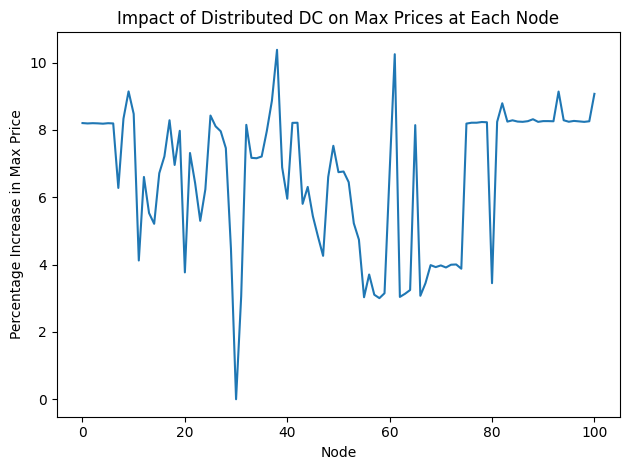

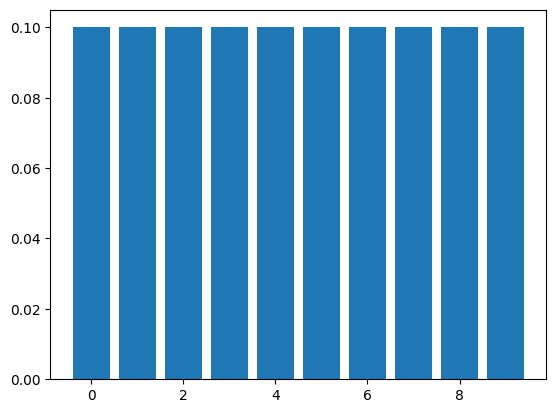

In [29]:
## Analyze results between base outcome and distributed case

base_outcome_dispatch_cost = base_outcome.problem.value
distributed_outcome_dispatch_cost = benders_distributed_outcome.problem.value

base_outcome_max_prices = base_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
distributed_outcome_max_prices = benders_distributed_outcome.prices.max(axis=1) # [101,] (max price over time at each node)
max_prices_diff_pct = (distributed_outcome_max_prices - base_outcome_max_prices) / base_outcome_max_prices * 100 # [101,] percentage increase in max price at each node

## Observe some results from the dispatch outcome
print(f"Dispatch Cost before injectio   n: {base_outcome_dispatch_cost}")
print(f"Dispatch Cost after distributed DC: {distributed_outcome_dispatch_cost}")
print(f"Dispatch Cost Increased by {(distributed_outcome_dispatch_cost - base_outcome_dispatch_cost)/base_outcome_dispatch_cost * 100:.2f}%")

injection_terminal = INVESTMENT_NODE_CANDS[0]
plt.plot(max_prices_diff_pct, label="Percentage Increase in Max Price at Each Node")
plt.xlabel("Node")
plt.ylabel("Percentage Increase in Max Price")
plt.title("Impact of Distributed DC on Max Prices at Each Node")
plt.tight_layout()


plt.figure()
plt.bar(range(len(benders_planned_dc_capacities)), benders_planned_dc_capacities)